# Module A: Lightweight DBMS with B+ Tree Index
## SafeDocs - Secure PDF Management System

**CS 432 - Databases | IIT Gandhinagar | Assignment 2**

**Team Members:**
- Sujal Patel (22110261)
- Siddharth Doshi (22110250)
- Viraj Vekaria (22110287)
- Nishit Mistry (22110172)
- Rutvi Shah (22110227)

---

## 1. Introduction

This report presents **Module A** of SafeDocs: a lightweight DBMS implemented in Python with a **B+ Tree** as its primary indexing structure. The aim is to support efficient insertion, deletion, search, update, and range-query operations while also exposing the internal tree structure clearly through visualization and benchmarking.

In Assignment 1, SafeDocs was designed as a secure PDF management system with entities such as members, documents, departments, roles, and audit logs. Module A focuses on the storage and indexing layer needed to support that schema efficiently. To make the performance trade-off concrete, the B+ Tree implementation is compared against a **BruteForceDB** baseline that stores data in a simple list and resolves operations through linear scans.

This notebook covers:
- the implementation details of the B+ Tree and supporting database abstractions
- demonstrations of the required core operations
- Graphviz visualizations showing node splits, merges, and leaf linkage
- automated benchmarking with Matplotlib plots and a summary table
- final conclusions, limitations, and future improvements

### Key Components
- **B+ Tree**: insertion, deletion, search, range queries, update, value storage, aggregation helpers, and Graphviz visualization.
- **BruteForceDB**: list-based key-value store with matching external behavior for fair benchmarking.
- **Table**: typed relational table with validation, strict primary-key enforcement, partial updates, and constraint-based search.
- **DatabaseManager**: manager for multiple named databases, each containing multiple tables.

### Video Demonstration

- **Video Link**: https://youtu.be/redhcqXd5tg
---

## 2. Implementation Details

### B+ Tree Structure
- **Order**: configurable (default `5`). Each internal node stores up to `order - 1` keys and `order` children.
- **Leaf nodes** store `(key, value)` pairs and are connected through `next` pointers for efficient range scans.
- **Internal nodes** store separator keys that guide traversal from the root to the correct leaf.
- **Insertion** uses proactive splitting so the algorithm descends only through non-full children.
- **Deletion** handles underflow by borrowing from siblings or merging nodes, while also updating separator keys when needed.
- **Size tracking** is maintained through an internal `_size` counter, so `len(tree)` is `O(1)`.

### Core Operations
| Operation | Description | Complexity |
|-----------|-------------|------------|
| Insert | Insert a key-value pair, splitting on overflow and updating value on duplicate key | O(log n) |
| Delete | Remove a key and rebalance through redistribution or merging | O(log n) |
| Search | Exact-match lookup from root to leaf | O(log n) |
| Range Query | Return all values in `[start, end]` by walking linked leaves | O(log n + k) |
| Update | Modify the value for an existing key | O(log n) |
| `min_key` / `max_key` | Reach leftmost or rightmost leaf | O(log n) |
| `count` / `len` | Return the tracked number of keys | O(1) |

### BruteForce Baseline
`BruteForceDB` stores records in a Python list and performs operations by linear iteration. It is intentionally simple and is kept API-compatible with the tree where practical so that the benchmark highlights the effect of indexing rather than unrelated interface differences.

### Table and DatabaseManager Layers
- **Table**: stores typed records using a schema of the form `{column: type}`, validates inserts and updates, enforces a strict primary key, and supports filtered search.
- **DatabaseManager**: manages multiple named databases, each containing multiple tables, so the B+ Tree can be used as the indexing layer beneath a simple relational interface.

In [1]:
import sys, os
MODULE_A_DIR = os.getcwd()
if MODULE_A_DIR not in sys.path:
    sys.path.insert(0, MODULE_A_DIR)
from database import BPlusTree, BPlusTreeNode, BruteForceDB, Table, DatabaseManager
print('All imports successful!')

All imports successful!


## 3. Demonstrating Core B+ Tree Operations
We demonstrate all operations using SafeDocs DocumentIDs as keys and document titles as values.

In [2]:
tree = BPlusTree(order=4)
documents = {
    1: 'CS432 Database Syllabus', 2: 'ML Research Paper', 3: 'Physics Lab Report',
    5: 'Operating Systems Notes', 7: 'Student Handbook 2025', 10: 'Linear Algebra Textbook',
    12: 'Data Structures Assignment', 15: 'Compiler Design Slides', 17: 'Network Security Guide',
    20: 'Cloud Computing Whitepaper', 22: 'AI Ethics Report', 25: 'Software Engineering Plan',
    28: 'Embedded Systems Manual', 30: 'Discrete Maths Solutions', 33: 'Cryptography Primer',
}
for doc_id, title in documents.items():
    tree.insert(doc_id, title)
print(f'Inserted {len(documents)} documents: {list(documents.keys())}')
print(f'Tree: {tree}')

# Exact Search
print(f'\nSearch(DocumentID=12): {tree.search(12)}')
print(f'Search(DocumentID=99): {tree.search(99)}')

# Contains
print(f'\ncontains(20): {tree.contains(20)}')
print(f'20 in tree: {20 in tree}, 99 in tree: {99 in tree}')

# Range Query
print(f'\nRange Query [10, 25]:')
for k, v in tree.range_query(10, 25):
    print(f'  DocumentID={k}: {v}')

# Update
tree.update(12, 'Data Structures Assignment (Updated v2)')
print(f'\nAfter update -- Search(12): {tree.search(12)}')

# Upsert
tree.insert(3, 'Physics Lab Report (Revised)')
print(f'After upsert(3): {tree.search(3)}, size still {len(tree)}')

# Delete
tree.delete(5)
print(f'\nAfter delete(5): contains={tree.contains(5)}, size={len(tree)}')

# Aggregation
print(f'\nmin_key={tree.min_key()}, max_key={tree.max_key()}')
print(f'count={tree.count()}, sum_keys={tree.sum_keys()}')
print(f'All IDs: {[k for k, v in tree.get_all()]}')

Inserted 15 documents: [1, 2, 3, 5, 7, 10, 12, 15, 17, 20, 22, 25, 28, 30, 33]
Tree: BPlusTree(order=4, size=15)

Search(DocumentID=12): Data Structures Assignment
Search(DocumentID=99): None

contains(20): True
20 in tree: True, 99 in tree: False

Range Query [10, 25]:
  DocumentID=10: Linear Algebra Textbook
  DocumentID=12: Data Structures Assignment
  DocumentID=15: Compiler Design Slides
  DocumentID=17: Network Security Guide
  DocumentID=20: Cloud Computing Whitepaper
  DocumentID=22: AI Ethics Report
  DocumentID=25: Software Engineering Plan

After update -- Search(12): Data Structures Assignment (Updated v2)
After upsert(3): Physics Lab Report (Revised), size still 15

After delete(5): contains=False, size=14

min_key=1, max_key=33
count=14, sum_keys=225
All IDs: [1, 2, 3, 7, 10, 12, 15, 17, 20, 22, 25, 28, 30, 33]


## 4. Database Integration (Table & DatabaseManager)

The `Table` class provides relational semantics: typed schema with validation, strict PK enforcement, partial updates, constraint-based search.
The `DatabaseManager` supports multiple named databases, each containing multiple tables -- matching the boilerplate architecture.

In [3]:
# Multi-database setup
db = DatabaseManager()
success, msg = db.create_database('SafeDocs')
print(f'Create database: {msg}')
print(f'Databases: {db.list_databases()}')

# Define typed schema and create table
member_schema = {
    'MemberID': int,
    'Name': str,
    'Email': str,
    'RoleID': int,
}
success, msg = db.create_table('SafeDocs', 'Members', member_schema, order=5, search_key='MemberID')
print(f'Create table: {msg}')

tables, _ = db.list_tables('SafeDocs')
print(f'Tables: {tables}')

# Get table handle
members_table, _ = db.get_table('SafeDocs', 'Members')

# Insert records
sample_members = [
    {'MemberID': 1, 'Name': 'Aarav Sharma', 'Email': 'aarav.sharma@iitgn.ac.in', 'RoleID': 1},
    {'MemberID': 2, 'Name': 'Priya Mehta', 'Email': 'priya.mehta@iitgn.ac.in', 'RoleID': 2},
    {'MemberID': 3, 'Name': 'Rohan Verma', 'Email': 'rohan.verma@iitgn.ac.in', 'RoleID': 3},
    {'MemberID': 4, 'Name': 'Sneha Iyer', 'Email': 'sneha.iyer@iitgn.ac.in', 'RoleID': 2},
    {'MemberID': 5, 'Name': 'Vikram Singh', 'Email': 'vikram.singh@iitgn.ac.in', 'RoleID': 3},
    {'MemberID': 6, 'Name': 'Ananya Reddy', 'Email': 'ananya.reddy@iitgn.ac.in', 'RoleID': 4},
    {'MemberID': 7, 'Name': 'Karthik Nair', 'Email': 'karthik.nair@iitgn.ac.in', 'RoleID': 3},
]
for m in sample_members:
    ok, result = members_table.insert(m)
    print(f'  Insert MemberID={m["MemberID"]}: {"OK" if ok else result}')
print(f'\nTable: {members_table}')

# Strict PK -- duplicate rejected
ok, result = members_table.insert({'MemberID': 1, 'Name': 'Dup', 'Email': 'x@x.com', 'RoleID': 1})
print(f'\nDuplicate insert: success={ok}, result="{result}"')

# Schema validation -- wrong type coerced
ok, result = members_table.insert({'MemberID': '8', 'Name': 'Test', 'Email': 'test@x.com', 'RoleID': '2'})
print(f'Insert with str IDs (coerced): success={ok}, result={result}')

# GET by key
print(f'\nGET MemberID=3: {members_table.get(3)}')

# GET all
print(f'\nAll records ({members_table.count()} rows):')
for key, rec in members_table.get_all():
    print(f'  {key}: {rec["Name"]} ({rec["Email"]})')

# Range Query on search key
print('\nRange Query [2, 5]:')
for key, rec in members_table.range_query(2, 5):
    print(f'  {key}: {rec["Name"]}')

# Partial update
ok, msg = members_table.update(2, {'Email': 'priya.updated@iitgn.ac.in'})
print(f'\nUpdate MemberID=2: {msg}')
print(f'After update: {members_table.get(2)}')

# Constraint-based search
print('\nSearch for RoleID=3:')
for key, rec in members_table.search({'RoleID': 3}):
    print(f'  {key}: {rec["Name"]}')

# DELETE
ok, msg = members_table.delete(6)
print(f'\nDelete MemberID=6: {msg}')
print(f'Count after delete: {members_table.count()}')

Create database: Database 'SafeDocs' created successfully
Databases: ['SafeDocs']
Create table: Table 'Members' created successfully in database 'SafeDocs'
Tables: ['Members']
  Insert MemberID=1: OK
  Insert MemberID=2: OK
  Insert MemberID=3: OK
  Insert MemberID=4: OK
  Insert MemberID=5: OK
  Insert MemberID=6: OK
  Insert MemberID=7: OK

Table: Table(name='Members', rows=7)

Duplicate insert: success=False, result="Duplicate key: 1"
Insert with str IDs (coerced): success=True, result=8

GET MemberID=3: {'MemberID': 3, 'Name': 'Rohan Verma', 'Email': 'rohan.verma@iitgn.ac.in', 'RoleID': 3}

All records (8 rows):
  1: Aarav Sharma (aarav.sharma@iitgn.ac.in)
  2: Priya Mehta (priya.mehta@iitgn.ac.in)
  3: Rohan Verma (rohan.verma@iitgn.ac.in)
  4: Sneha Iyer (sneha.iyer@iitgn.ac.in)
  5: Vikram Singh (vikram.singh@iitgn.ac.in)
  6: Ananya Reddy (ananya.reddy@iitgn.ac.in)
  7: Karthik Nair (karthik.nair@iitgn.ac.in)
  8: Test (test@x.com)

Range Query [2, 5]:
  2: Priya Mehta
  3: Roh

## 5. Visualization (Graphviz)

Graphviz renders the tree with HTML-table labels:
- **Internal nodes** (blue) with separator keys
- **Leaf nodes** (green) with data keys
- **Leaf linked list** (red dashed arrows)

SafeDocs Document Index: BPlusTree(order=4, size=12)


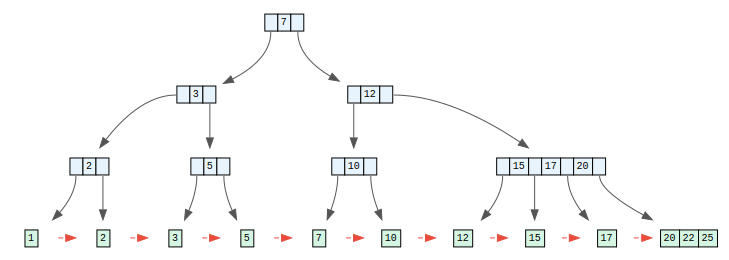

In [4]:
# Document index tree
tree_viz = BPlusTree(order=4)
for doc_id in [1, 2, 3, 5, 7, 10, 12, 15, 17, 20, 22, 25]:
    tree_viz.insert(doc_id, f'Document_{doc_id}')
print(f'SafeDocs Document Index: {tree_viz}')
tree_viz.visualize_tree()

Members table B+ Tree index:


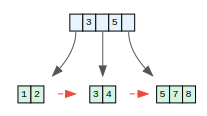

In [5]:
# Members table index
print('Members table B+ Tree index:')
members_table.visualize_index()

Before deletion (DocumentIDs 1-15, size=15):


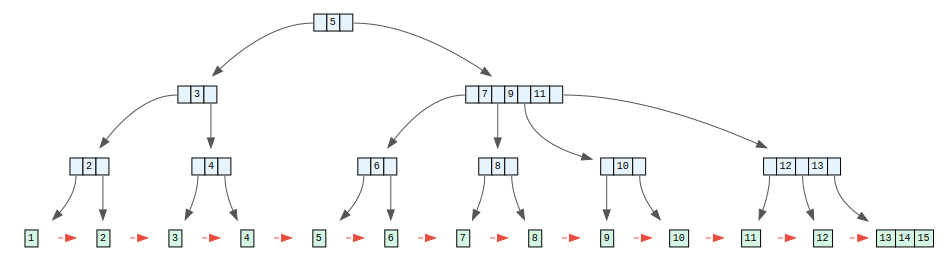


After deleting [3, 6, 9, 12] (size=11):


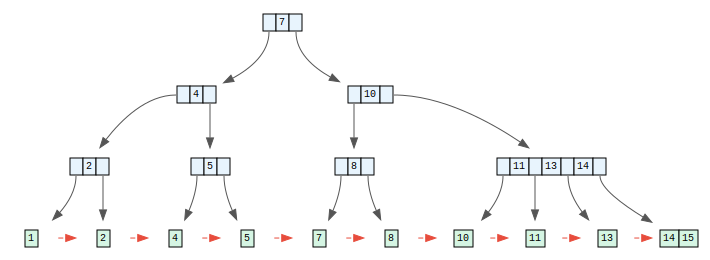

In [6]:
# Before and after deletion
tree_del = BPlusTree(order=4)
for doc_id in range(1, 16):
    tree_del.insert(doc_id, f'Document_{doc_id}')
print(f'Before deletion (DocumentIDs 1-15, size={len(tree_del)}):')
display(tree_del.visualize_tree())

for doc_id in [3, 6, 9, 12]:
    tree_del.delete(doc_id)
print(f'\nAfter deleting [3, 6, 9, 12] (size={len(tree_del)}):')
display(tree_del.visualize_tree())

Step-by-step: inserting keys into order-3 B+ Tree

After inserting 10 (size=1):


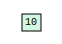


After inserting 20 (size=2):


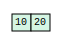


After inserting 5 (size=3):


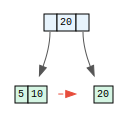


After inserting 15 (size=4):


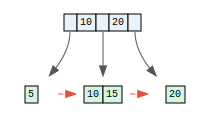


After inserting 25 (size=5):


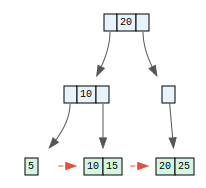


After inserting 30 (size=6):


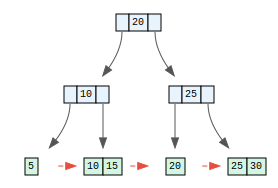


After inserting 7 (size=7):


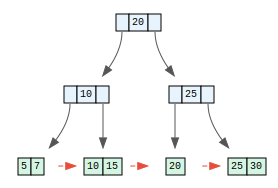

In [7]:
# Step-by-step insertion (order=3 for frequent splits)
print('Step-by-step: inserting keys into order-3 B+ Tree\n')
step_tree = BPlusTree(order=3)
for k in [10, 20, 5, 15, 25, 30, 7]:
    step_tree.insert(k, f'val_{k}')
    print(f'After inserting {k} (size={len(step_tree)}):')
    display(step_tree.visualize_tree())
    print()

## 6. Performance Analysis

To evaluate scalability, the B+ Tree is benchmarked against `BruteForceDB` on randomly generated integer keys. For each dataset size, the notebook generates a fresh duplicate-free key set using `random.sample(range(n * 10), n)` so both data structures receive the same workload.

### Benchmark Methodology
1. Insert the full key set into both data structures.
2. Perform up to 100 random exact-match searches.
3. Perform up to 100 random deletions on fresh copies.
4. Perform up to 100 narrow range queries.
5. Execute 200 mixed random operations to simulate a more realistic workload.
6. Record peak memory usage with `tracemalloc`.

### Experimental Setup
- Dataset sizes: **100 to 20,000 keys** across 12 data points.
- Timer: `time.perf_counter()`.
- Plots: generated with **Matplotlib**.
- Memory metric: peak allocated memory in KB.

This setup directly addresses the assignment requirement to compare insertion, search, deletion, and range-query efficiency, while also adding mixed-workload and memory measurements for a fuller picture.

In [8]:
import time, random, tracemalloc
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

class PerformanceAnalyzer:
    SIZES = [100, 250, 500, 1000, 2000, 3000, 5000, 7500, 10000, 13000, 16000, 20000]

    def __init__(self, sizes=None, order=5):
        self.sizes = sizes or self.SIZES
        self.order = order
        self.results = {}

    @staticmethod
    def _time_op(func):
        start = time.perf_counter()
        func()
        return time.perf_counter() - start

    def run_all(self):
        metrics = ['insertion', 'search', 'deletion', 'range_query', 'random_ops', 'memory']
        self.results = {m: {'bptree': [], 'bruteforce': []} for m in metrics}
        self.results['sizes'] = self.sizes

        for n in self.sizes:
            keys = random.sample(range(n * 10), n)
            search_keys = random.sample(keys, min(100, n))
            delete_keys = random.sample(keys, min(100, n))

            # Insertion
            tree = BPlusTree(order=self.order)
            bf = BruteForceDB()
            t_bp = self._time_op(lambda: [tree.insert(k, k) for k in keys])
            t_bf = self._time_op(lambda: [bf.insert(k, k) for k in keys])
            self.results['insertion']['bptree'].append(t_bp)
            self.results['insertion']['bruteforce'].append(t_bf)

            # Search
            t_bp = self._time_op(lambda: [tree.search(k) for k in search_keys])
            t_bf = self._time_op(lambda: [bf.search(k) for k in search_keys])
            self.results['search']['bptree'].append(t_bp)
            self.results['search']['bruteforce'].append(t_bf)

            # Range Query
            width = max(1, n // 100)
            qranges = [(lo, lo + width) for lo in random.sample(range(0, n*10 - width), min(100, n))]
            t_bp = self._time_op(lambda: [tree.range_query(lo, hi) for lo, hi in qranges])
            t_bf = self._time_op(lambda: [bf.range_query(lo, hi) for lo, hi in qranges])
            self.results['range_query']['bptree'].append(t_bp)
            self.results['range_query']['bruteforce'].append(t_bf)

            # Memory (tracemalloc)
            tracemalloc.start()
            tree_m = BPlusTree(order=self.order)
            for k in keys: tree_m.insert(k, k)
            _, peak_bp = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            tracemalloc.start()
            bf_m = BruteForceDB()
            for k in keys: bf_m.insert(k, k)
            _, peak_bf = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            self.results['memory']['bptree'].append(peak_bp / 1024)
            self.results['memory']['bruteforce'].append(peak_bf / 1024)

            # Deletion (fresh copies)
            tree2 = BPlusTree(order=self.order)
            bf2 = BruteForceDB()
            for k in keys:
                tree2.insert(k, k)
                bf2.insert(k, k)
            t_bp = self._time_op(lambda: [tree2.delete(k) for k in delete_keys])
            t_bf = self._time_op(lambda: [bf2.delete(k) for k in delete_keys])
            self.results['deletion']['bptree'].append(t_bp)
            self.results['deletion']['bruteforce'].append(t_bf)

            # Random Mixed Ops (200)
            tree3 = BPlusTree(order=self.order)
            bf3 = BruteForceDB()
            for k in keys[:n//2]:
                tree3.insert(k, k)
                bf3.insert(k, k)
            ops = [(random.choice(['insert','search','delete']), random.choice(keys)) for _ in range(200)]
            def run_ops(ds):
                for op, k in ops:
                    if op == 'insert': ds.insert(k, k)
                    elif op == 'search': ds.search(k)
                    elif op == 'delete': ds.delete(k)
            t_bp = self._time_op(lambda: run_ops(tree3))
            t_bf = self._time_op(lambda: run_ops(bf3))
            self.results['random_ops']['bptree'].append(t_bp)
            self.results['random_ops']['bruteforce'].append(t_bf)

            print(f'  n={n:>7d}  done')
        return self.results

print('PerformanceAnalyzer defined.')

PerformanceAnalyzer defined.


In [9]:
print('Running benchmarks...')
analyzer = PerformanceAnalyzer(order=5)
results = analyzer.run_all()
print('\nAll benchmarks complete!')

Running benchmarks...
  n=    100  done
  n=    250  done
  n=    500  done
  n=   1000  done


  n=   2000  done


  n=   3000  done


  n=   5000  done


  n=   7500  done


  n=  10000  done


  n=  13000  done


  n=  16000  done


  n=  20000  done

All benchmarks complete!


### 6.1 Performance Plots

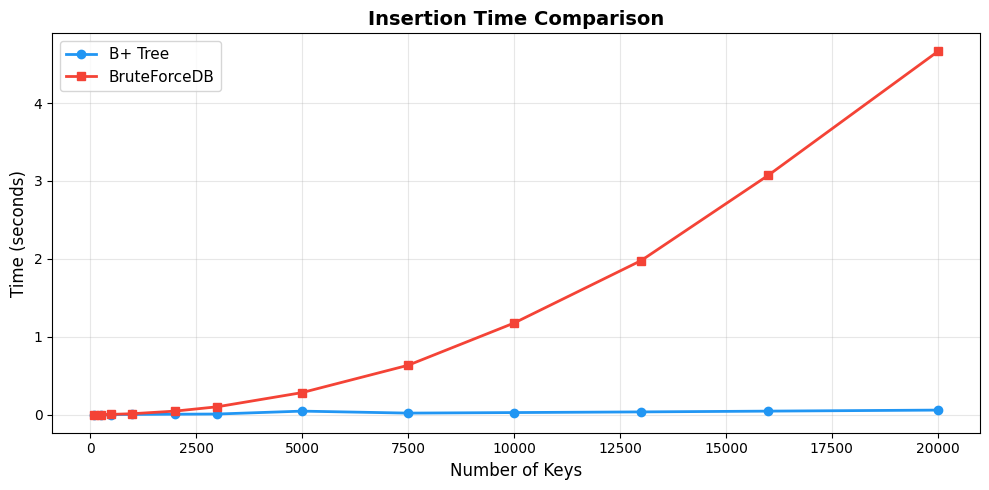

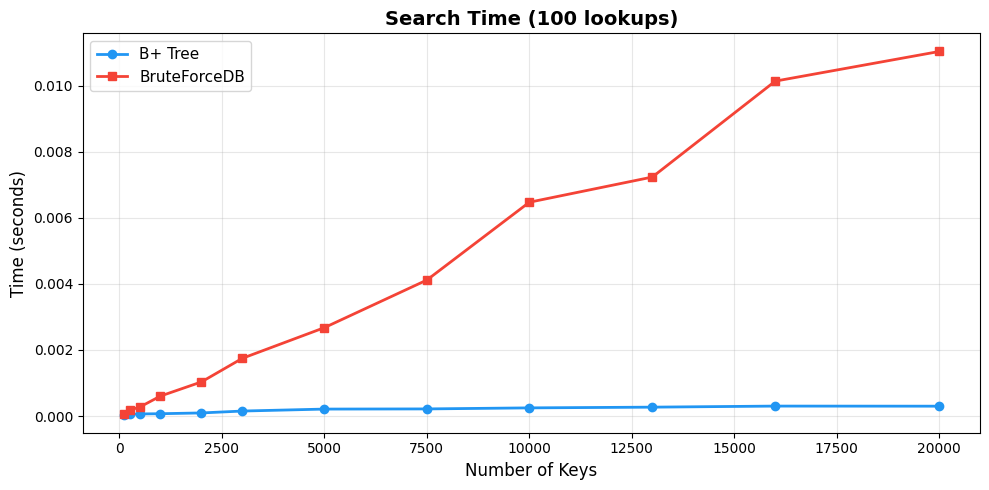

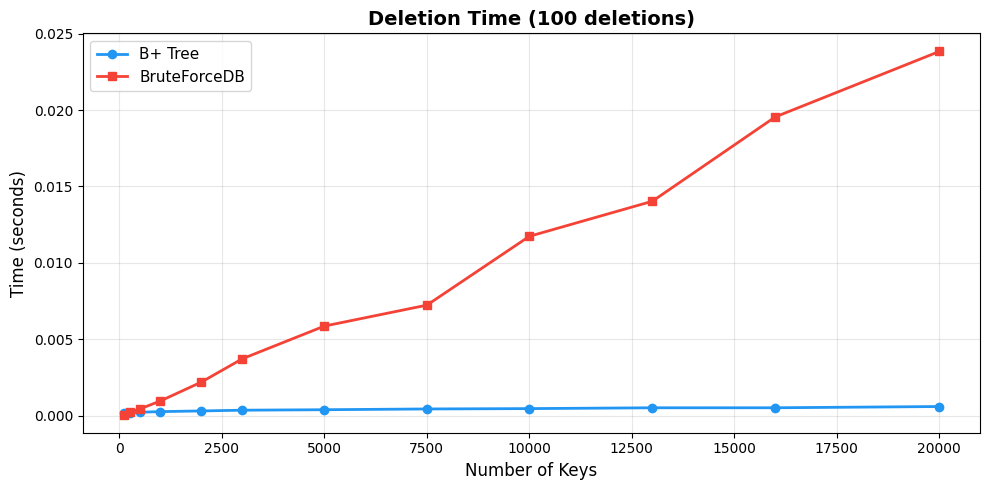

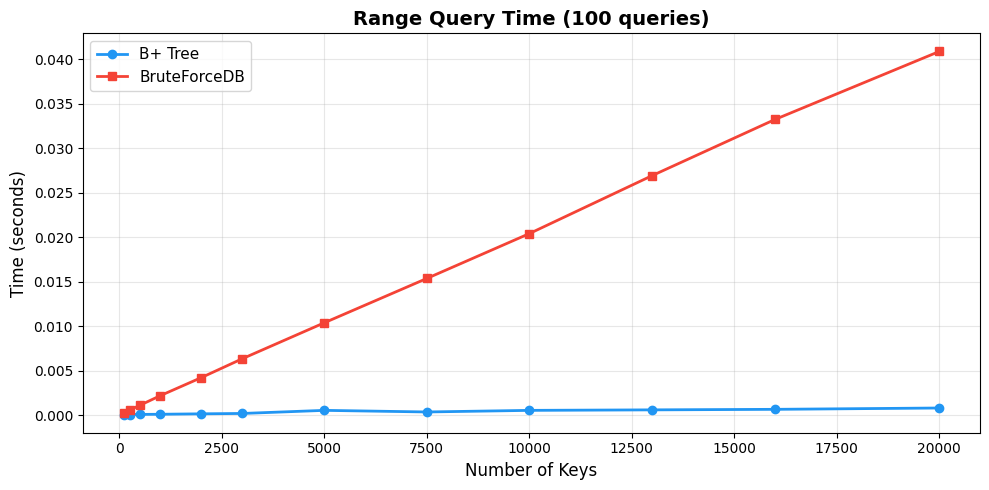

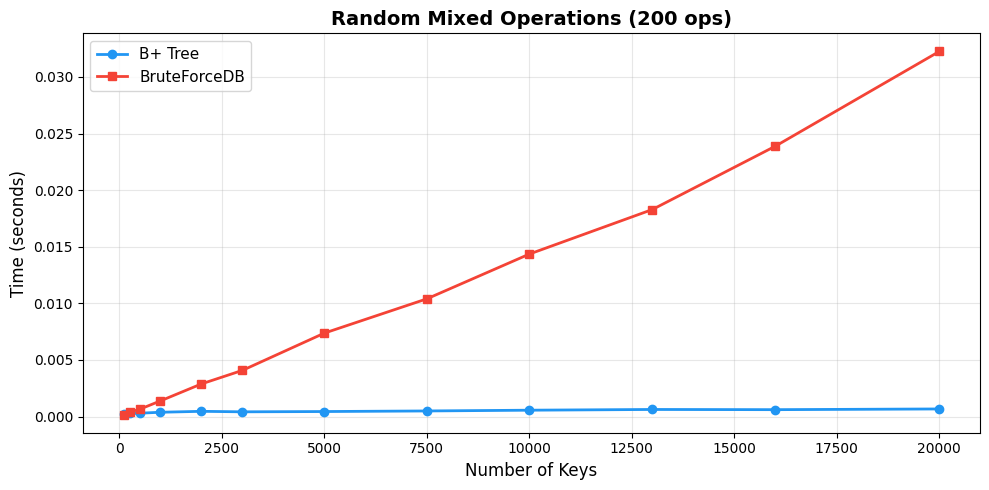

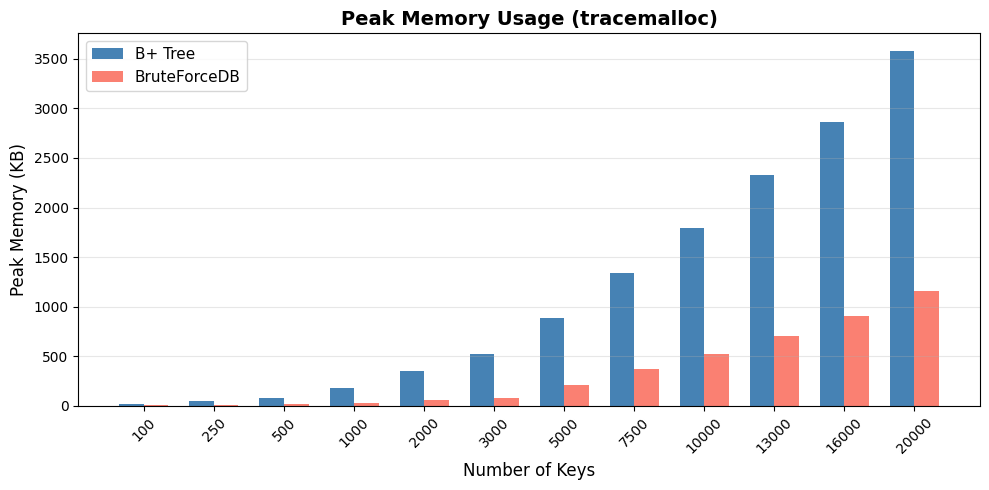

In [10]:
def plot_benchmark(sizes, data, title, ylabel):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(sizes, data['bptree'], 'o-', label='B+ Tree', color='#2196F3', linewidth=2)
    ax.plot(sizes, data['bruteforce'], 's-', label='BruteForceDB', color='#F44336', linewidth=2)
    ax.set_xlabel('Number of Keys', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_memory_bar(sizes, data):
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(sizes))
    w = 0.35
    ax.bar(x - w/2, data['bptree'], w, label='B+ Tree', color='steelblue')
    ax.bar(x + w/2, data['bruteforce'], w, label='BruteForceDB', color='salmon')
    ax.set_xlabel('Number of Keys', fontsize=12)
    ax.set_ylabel('Peak Memory (KB)', fontsize=12)
    ax.set_title('Peak Memory Usage (tracemalloc)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([str(s) for s in sizes], rotation=45)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

sizes = results['sizes']
plot_benchmark(sizes, results['insertion'], 'Insertion Time Comparison', 'Time (seconds)')
plot_benchmark(sizes, results['search'], 'Search Time (100 lookups)', 'Time (seconds)')
plot_benchmark(sizes, results['deletion'], 'Deletion Time (100 deletions)', 'Time (seconds)')
plot_benchmark(sizes, results['range_query'], 'Range Query Time (100 queries)', 'Time (seconds)')
plot_benchmark(sizes, results['random_ops'], 'Random Mixed Operations (200 ops)', 'Time (seconds)')
plot_memory_bar(sizes, results['memory'])

### 6.2 Summary Table

In [11]:
print(f"{'Metric':<25} {'B+ Tree':>15} {'BruteForce':>15} {'Speedup':>10}")
print('-' * 68)
for metric, label, unit in [
    ('insertion', 'Insertion', 's'),
    ('search', 'Search (100)', 's'),
    ('deletion', 'Deletion (100)', 's'),
    ('range_query', 'Range Query (100)', 's'),
    ('random_ops', 'Random Ops (200)', 's'),
    ('memory', 'Peak Memory', 'KB'),
]:
    bpt = results[metric]['bptree'][-1]
    bf = results[metric]['bruteforce'][-1]
    sp = bf / bpt if bpt > 0 else float('inf')
    if unit == 's':
        print(f'{label:<25} {bpt:>13.6f}s {bf:>13.6f}s {sp:>9.2f}x')
    else:
        print(f'{label:<25} {bpt:>12.1f}KB {bf:>12.1f}KB {sp:>9.2f}x')

Metric                            B+ Tree      BruteForce    Speedup
--------------------------------------------------------------------
Insertion                      0.057588s      4.661454s     80.95x
Search (100)                   0.000299s      0.011034s     36.91x
Deletion (100)                 0.000598s      0.023834s     39.89x
Range Query (100)              0.000796s      0.040875s     51.38x
Random Ops (200)               0.000672s      0.032250s     47.97x
Peak Memory                     3579.2KB       1154.8KB      0.32x


### Performance Discussion

The benchmark results consistently show why B+ Trees are the standard indexing structure in database systems.

- **Insertion** scales better in the B+ Tree because the height of the tree grows slowly, while the brute-force baseline must do increasingly expensive linear work as the dataset grows.
- **Search** benefits strongly from root-to-leaf navigation, giving logarithmic behavior instead of a full scan.
- **Deletion** remains efficient because rebalancing is local to neighboring nodes even when borrowing or merging is required.
- **Range queries** show the clearest structural advantage: after the start key is located, the query can continue through linked leaves without revisiting upper tree levels or scanning unrelated keys.
- **Mixed operations** confirm that the advantage is not limited to one isolated workload; the tree stays efficient under insert/search/delete combinations similar to real database usage.
- **Memory usage** is higher for the B+ Tree because nodes store keys, pointers, and structural metadata. This is the expected time-space trade-off for obtaining faster lookups and range scans.

| Operation | B+ Tree | BruteForceDB |
|-----------|---------|-------------|
| Insert | O(log n) | O(n) |
| Search | O(log n) | O(n) |
| Delete | O(log n) | O(n) |
| Range Query | O(log n + k) | O(n) |
| `len` / `count` | O(1) | O(1) |

## 7. Conclusion

This module implements the required **B+ Tree database functionality**: insertion, deletion, search, range queries, update, and value storage. The implementation is supported by typed table abstractions, Graphviz visualizations, and automated benchmarks against a brute-force baseline.

### Main Findings
- The B+ Tree outperforms the brute-force approach increasingly clearly as dataset size grows.
- Exact search and deletion benefit from logarithmic traversal.
- Range queries benefit the most because linked leaf nodes support efficient sequential access.
- The higher memory footprint is acceptable given the substantial performance improvement.

### Implementation Challenges
- Correctly distinguishing leaf splits from internal-node splits.
- Preserving leaf-node linkage during insertions, deletions, and merges.
- Updating separator keys after deletion and redistribution.
- Maintaining accurate size bookkeeping during inserts, updates, and deletes.

### Future Improvements
- Disk-backed persistence for larger datasets.
- Composite and multi-column keys.
- Bulk loading for faster initial tree construction.
- Concurrency control and recovery mechanisms.

---

### Video Demonstration

[Video Link](https://youtu.be/redhcqXd5tg)